# Surface renewal on one day of real data — WES almond orchard, 24 June 2023

This notebook runs both `srflux` detectors end to end on a single day from an almond
orchard eddy-covariance site, and calibrates them against the tower.

**What is in `examples/data/`**

| file | contents |
|---|---|
| `wes_2023-06-24_1hz.csv.gz` | 1 Hz **FWT** (fine-wire thermocouple, air) and **IRT** (radiometer, canopy skin), 86,400 samples |
| `wes_2023-06-24_flux30.csv` | 30-min **NETRAD**, **G**, **H**, **LE** from the tower (48 blocks) |

Nothing else is needed: the two temperature series are the surface-renewal input, and the
four flux terms are the reference and the energy balance.

The two scalars are a deliberate contrast. FWT sits in the air and sees the sharp
microfronts directly; IRT looks at the canopy skin, whose ramps are smoother, smaller and
harder to detect — which is exactly where surface renewal is most useful, because a
radiometer is cheap and needs no sonic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from srflux import (HaarDetector, VanAttaDetector, prepare_block, ramp_flux,
                    calibrate_alpha, fit_and_score, sensible_heat,
                    latent_heat_residual, daily_et, sign_from_skewness)
from srflux.preprocess import increment_skewness

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

FS = 1.0            # Hz, the raw sampling rate
BLOCK_S = 1800.0    # 30-min averaging period
Z_AIR = 7.5         # m, sonic/fine-wire measurement height
Z_CANOPY = 3.5      # m, canopy height -- the right length scale for a SKIN temperature

hi = pd.read_csv("data/wes_2023-06-24_1hz.csv.gz", parse_dates=["TIMESTAMP"])
fx = pd.read_csv("data/wes_2023-06-24_flux30.csv", parse_dates=["TIMESTAMP"])
hi = hi.set_index("TIMESTAMP")
fx = fx.set_index("TIMESTAMP")

print(hi.describe().round(2).to_string())
fx.head()

            FWT       IRT
count  86400.00  86400.00
mean      23.85     20.83
std        9.37      8.46
min        9.77      9.90
25%       14.97     13.31
50%       21.59     18.37
75%       32.81     29.58
max       38.98     35.16


,NETRAD,G,H,LE
TIMESTAMP,,,,
2023-06-24 00:00:00,-81.14,43.89,-4.47,-0.20
2023-06-24 00:30:00,-74.48,-16.11,-8.52,-0.26
2023-06-24 01:00:00,-80.23,-18.91,-3.39,-0.78
2023-06-24 01:30:00,-77.99,-20.82,-3.65,-0.11
2023-06-24 02:00:00,-70.91,-20.93,-1.20,-0.15


## 1. The day at a glance

Top: the two raw 1 Hz series. The fine wire tracks air temperature and is visibly noisier;
the canopy skin runs *below* air through the middle of the day, which is what a transpiring
orchard should do — evaporative cooling holds the leaves below the air around them.

Bottom: the surface energy balance. This is an irrigated orchard in June, so most of the
available energy goes into LE, and H is the smaller term. That matters later: an error in
the surface-renewal H is diluted when ET is computed as a residual.

daytime Bowen ratio  H/LE = 0.73
energy-balance closure (H+LE)/(Rn-G) = 1.00


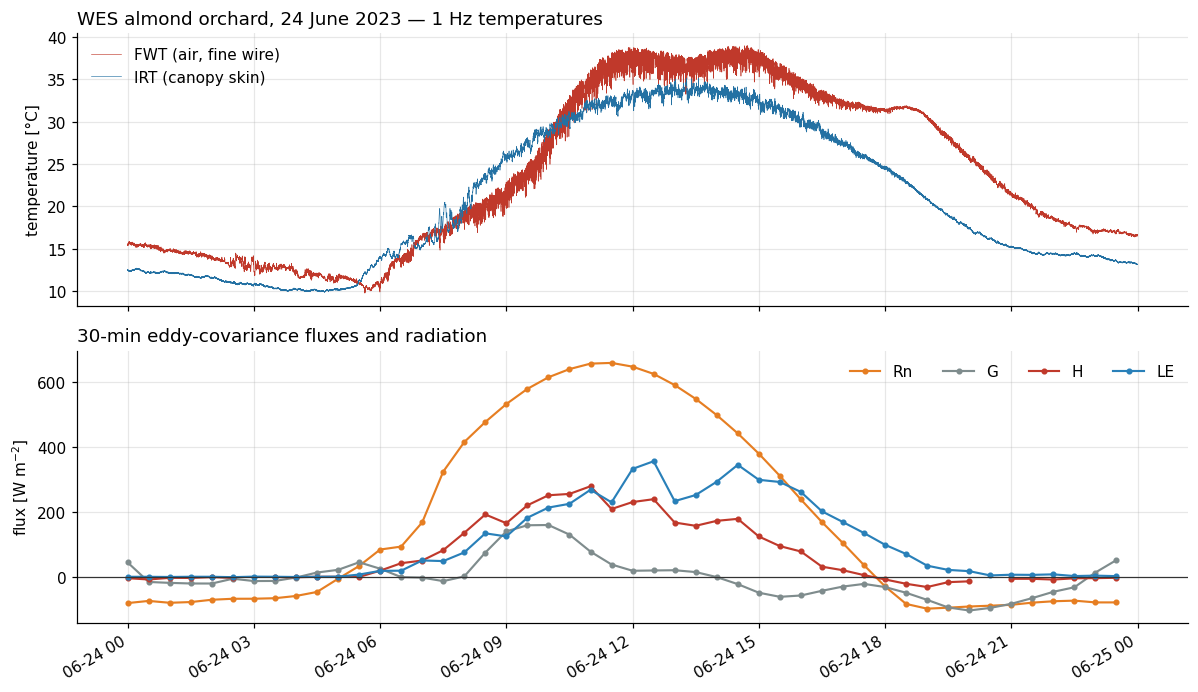

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1]))

ax1.plot(hi.index, hi.FWT, lw=0.4, color="#c0392b", label="FWT (air, fine wire)")
ax1.plot(hi.index, hi.IRT, lw=0.4, color="#2471a3", label="IRT (canopy skin)")
ax1.set_ylabel("temperature [°C]")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("WES almond orchard, 24 June 2023 — 1 Hz temperatures", loc="left")

for col, clr, lab in [("NETRAD", "#e67e22", "Rn"), ("G", "#7f8c8d", "G"),
                      ("H", "#c0392b", "H"), ("LE", "#2980b9", "LE")]:
    ax2.plot(fx.index, fx[col], "-o", ms=3, lw=1.4, color=clr, label=lab)
ax2.axhline(0, color="#333", lw=0.8)
ax2.set_ylabel("flux [W m$^{-2}$]")
ax2.legend(ncol=4, frameon=False)
ax2.set_title("30-min eddy-covariance fluxes and radiation", loc="left")
fig.autofmt_xdate()
plt.tight_layout()

closure = (fx.H + fx.LE).sum() / (fx.NETRAD - fx.G).sum()
print(f"daytime Bowen ratio  H/LE = {fx.H[fx.NETRAD > 50].sum() / fx.LE[fx.NETRAD > 50].sum():.2f}")
print(f"energy-balance closure (H+LE)/(Rn-G) = {closure:.2f}")

## 2. What a ramp actually looks like

One 30-min block at midday, for both scalars. The top panels show the raw series with its
300 s moving mean; the bottom panels show the detrended signal and the Haar coefficients,
with the detected microfronts marked.

Detection runs on the whole 30-min block; the plot shows the first few minutes so the
individual ramps stay legible. Note the difference in vertical scale — the air ramps are
several times larger than the skin ramps — and look at the asymmetry of each ramp, which
is what section 6 turns out to depend on.

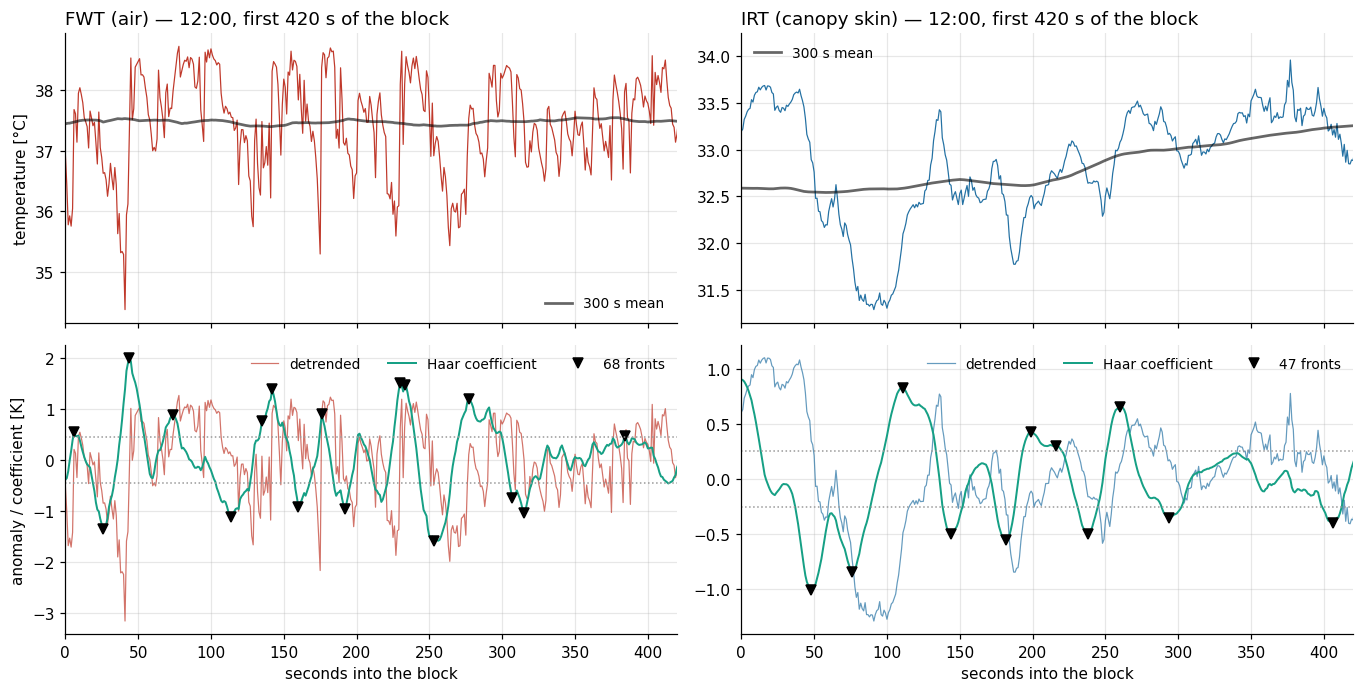

In [3]:
from srflux.preprocess import moving_average

t0 = pd.Timestamp("2023-06-24 12:00:00")
ZOOM_S = 420          # plot this many seconds so individual ramps stay legible
seg = hi.loc[t0:t0 + pd.Timedelta(seconds=BLOCK_S - 1)]
det = HaarDetector(fs=FS)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4), sharex=True)
for j, (col, clr, lab) in enumerate([("FWT", "#c0392b", "FWT (air)"),
                                     ("IRT", "#2471a3", "IRT (canopy skin)")]):
    v = prepare_block(seg[col].to_numpy(), fs=FS).values
    t = np.arange(len(v))
    coef = det.coefficients(v)
    res = det.detect(v)
    idx = res.extra["front_index"]

    axes[0, j].plot(t, v, lw=0.8, color=clr)
    axes[0, j].plot(t, moving_average(v, 300, FS), lw=1.8, color="k", alpha=0.6,
                    label="300 s mean")
    axes[0, j].set_title(f"{lab} — {t0:%H:%M}, first {ZOOM_S} s of the block", loc="left")
    axes[0, j].legend(frameon=False, fontsize=9)

    axes[1, j].plot(t, v - moving_average(v, 300, FS), lw=0.8, color=clr, alpha=0.7,
                    label="detrended")
    axes[1, j].plot(t, coef, lw=1.3, color="#16a085", label="Haar coefficient")
    axes[1, j].plot(idx, coef[idx], "v", ms=6, color="#000000",
                    label=f"{res.count} fronts")
    axes[1, j].axhline(res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].axhline(-res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].set_xlabel("seconds into the block")
    axes[1, j].set_xlim(0, ZOOM_S)          # detection uses the whole block; we plot a window
    axes[1, j].legend(frameon=False, fontsize=9, ncol=3)

axes[0, 0].set_ylabel("temperature [°C]")
axes[1, 0].set_ylabel("anomaly / coefficient [K]")
plt.tight_layout()

## 3. Run both detectors on every block

`HaarDetector` (SR-WL) counts fronts and reports their median amplitude; `VanAttaDetector`
(SR-VA) solves the structure-function cubic and reports an amplitude and a ramp period.

Each is turned into an uncalibrated flux with the appropriate length scale — the
measurement height for the air series, the canopy height for the skin series, since the
renewed volume against a canopy skin temperature is the canopy layer.

In [4]:
wl, va = HaarDetector(fs=FS), VanAttaDetector(fs=FS, lag="chen")
Z = {"FWT": Z_AIR, "IRT": Z_CANOPY}

rows = []
for t, g in hi.groupby(pd.Grouper(freq="30min")):
    row = {"TIMESTAMP": t}
    for col in ("FWT", "IRT"):
        qc = prepare_block(g[col].to_numpy(), fs=FS)
        if not qc.ok:
            continue
        rw, rv = wl.detect(qc.values), va.detect(qc.values)
        row[f"{col}_sign"] = sign_from_skewness(qc.values, fs=FS)
        row[f"{col}_skew"] = increment_skewness(qc.values, fs=FS)
        if rw.valid:
            row[f"WL_{col}_N"] = rw.count
            row[f"WL_{col}_A"] = rw.amplitude
            row[f"WL_{col}_F"] = ramp_flux(rw.amplitude, count=rw.count, z=Z[col],
                                           block_s=BLOCK_S)
        if rv.valid:
            row[f"VA_{col}_A"] = rv.amplitude
            row[f"VA_{col}_tau"] = rv.period
            row[f"VA_{col}_lag"] = rv.extra["lag_s"]
            row[f"VA_{col}_F"] = ramp_flux(rv.amplitude, period=rv.period, z=Z[col])
    rows.append(row)

sr = pd.DataFrame(rows).set_index("TIMESTAMP")
d = fx.join(sr)
d["daytime"] = d.NETRAD > 50
day_all = d[d.daytime]

print("median ramp statistics over the day")
print(pd.DataFrame({
    "WL count": [d.WL_FWT_N.median(), d.WL_IRT_N.median()],
    "WL amplitude [K]": [d.WL_FWT_A.median(), d.WL_IRT_A.median()],
    "VA amplitude [K]": [d.VA_FWT_A.median(), d.VA_IRT_A.median()],
    "VA period [s]": [d.VA_FWT_tau.median(), d.VA_IRT_tau.median()],
    "VA Chen lag [s]": [d.VA_FWT_lag.median(), d.VA_IRT_lag.median()],
}, index=["FWT (air)", "IRT (skin)"]).round(2).to_string())

median ramp statistics over the day
            WL count  WL amplitude [K]  VA amplitude [K]  VA period [s]  VA Chen lag [s]
FWT (air)       61.5              0.21              0.56          18.34              2.0
IRT (skin)      60.0              0.12              0.28         107.95             83.0


The Chen lag is the number to look at. It adapts to the scalar: a couple of seconds on the
fine wire, tens of seconds on the skin temperature. A fixed 1 s lag — the textbook choice
for a sonic — would have collapsed on the IRT series.

## 4. Uncalibrated flux against the tower

Before any calibration, the shape is already right: the surface-renewal quantity rises and
falls with H through the day. Calibration is a single multiplicative constant.

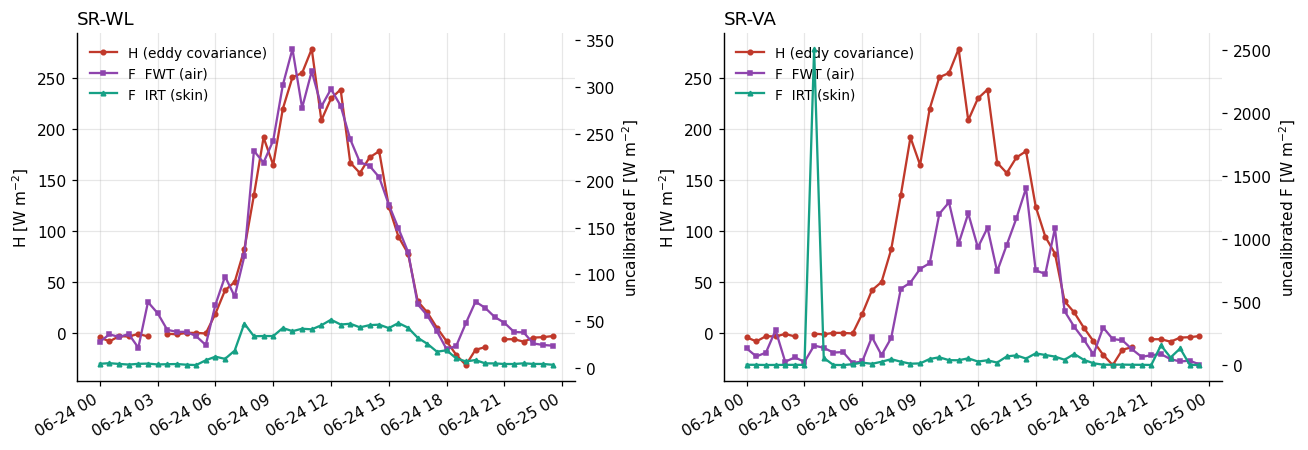

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, meth in zip(axes, ["WL", "VA"]):
    ax2 = ax.twinx()
    ax.plot(d.index, d.H, "-o", ms=3, color="#c0392b", label="H (eddy covariance)")
    ax2.plot(d.index, d[f"{meth}_FWT_F"], "-s", ms=3, color="#8e44ad",
             label="F  FWT (air)")
    ax2.plot(d.index, d[f"{meth}_IRT_F"], "-^", ms=3, color="#16a085",
             label="F  IRT (skin)")
    ax.set_ylabel("H [W m$^{-2}$]")
    ax2.set_ylabel("uncalibrated F [W m$^{-2}$]")
    ax2.grid(False)
    ax.set_title(f"SR-{meth}", loc="left")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9, loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()

## 5. Calibrate α and regress against H

α is fitted **through the origin** on convective daytime blocks only (Rn > 50 W m⁻² and
H > 0), so the ramp direction never enters the calibration. With a single day there are
only ~20 usable blocks, so treat these α values as illustrative — the transferability study
behind this package needed 10–21 days spread over the record before α settled to ±10 %.

,method,scalar,z [m],alpha,alpha*z [m],r,RMSE,n
0,SR-WL,FWT,7.5,0.76,5.70,0.97,22.75,23
1,SR-WL,IRT,3.5,3.92,13.71,0.63,62.79,23
2,SR-VA,FWT,7.5,0.19,1.39,0.78,51.30,23
3,SR-VA,IRT,3.5,2.43,8.50,-0.07,108.47,23


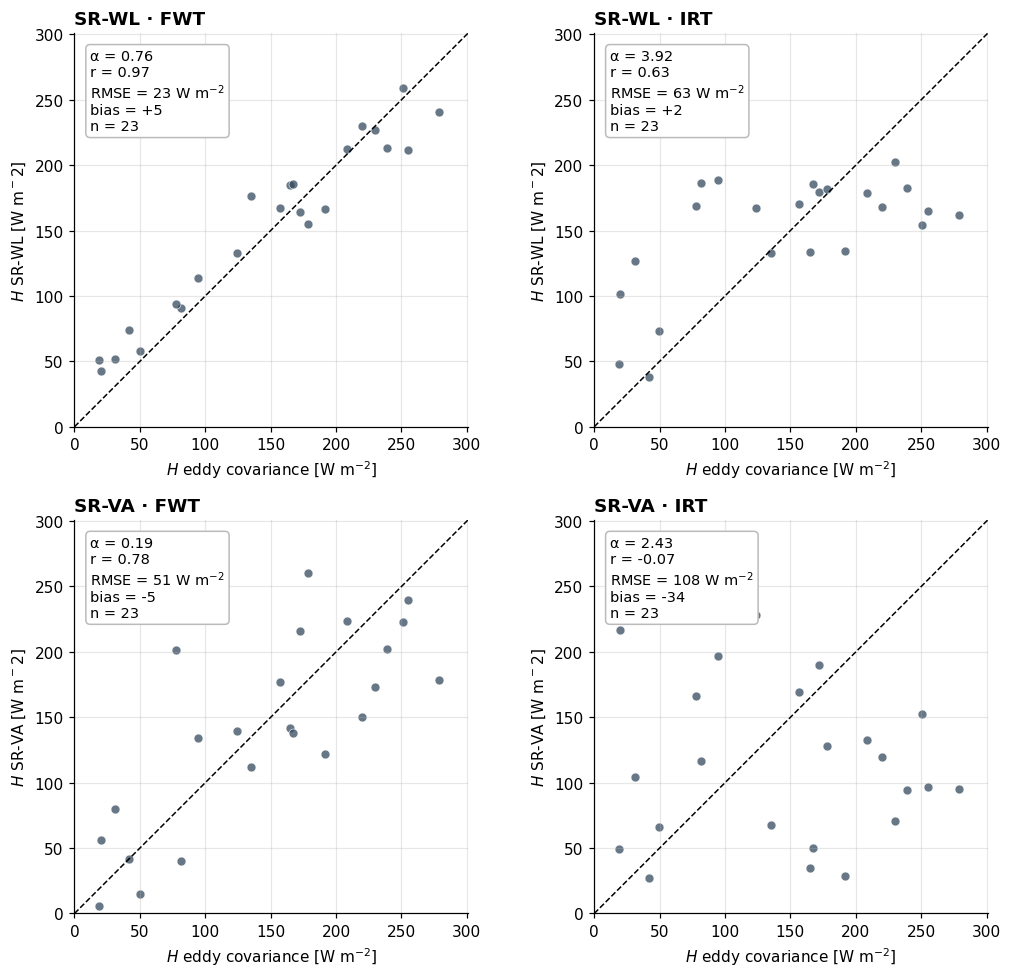

In [6]:
combos = [("WL", "FWT"), ("WL", "IRT"), ("VA", "FWT"), ("VA", "IRT")]
cal = d[d.daytime & (d.H > 0)]

fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.0))
fits = {}
for ax, (meth, col) in zip(axes.ravel(), combos):
    F, H = cal[f"{meth}_{col}_F"].to_numpy(), cal.H.to_numpy()
    m = np.isfinite(F) & np.isfinite(H)
    fit = fit_and_score(F[m], H[m])
    fits[(meth, col)] = fit
    est = fit.alpha * F[m]

    lim = [0, max(est.max(), H[m].max()) * 1.08]
    ax.scatter(H[m], est, s=34, color="#34495e", alpha=0.75, edgecolors="white", lw=0.5)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set(xlim=lim, ylim=lim, aspect="equal")
    ax.set_xlabel("$H$ eddy covariance [W m$^{-2}$]")
    ax.set_ylabel(f"$H$ SR-{meth} [W m$^{-2}$]")
    ax.set_title(f"SR-{meth} · {col}", loc="left", fontweight="bold")
    ax.text(0.04, 0.96, f"α = {fit.alpha:.2f}\nr = {fit.r:.2f}\nRMSE = {fit.rmse:.0f} W m$^{{-2}}$\n"
                        f"bias = {fit.mbe:+.0f}\nn = {fit.n}",
            transform=ax.transAxes, va="top", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", ec="#bbb"))
plt.tight_layout()

pd.DataFrame([{"method": f"SR-{m}", "scalar": c, "z [m]": Z[c], "alpha": f.alpha,
               "alpha*z [m]": f.alpha * Z[c], "r": f.r, "RMSE": f.rmse, "n": f.n}
              for (m, c), f in fits.items()]).round(2)

Two things to read off this table rather than the α column alone:

- **α and z are not separately identifiable.** Only their product enters the flux, so `α·z`
  is the quantity the data constrain. Comparing raw α between the air and skin channels
  compares two different height conventions, not two different physics.
- **r is scale-invariant.** It does not depend on α at all, so it — not RMSE — is the honest
  measure of which detector and which scalar tracks the flux better.

## 6. Does the pure surface-renewal sign work here? (no, and that is worth seeing)

Before the energy balance, the flux DIRECTION has to come from somewhere. The
temperature-only convention says a warm, upward-flux ramp rises gradually and collapses
sharply, leaving the increment distribution negatively skewed — so `sign_from_skewness`
returns +1 when the skewness is below a threshold.

On this day the fine wire does the opposite.

In [7]:
diag = []
for col in ("FWT", "IRT"):
    sg = day_all[f"{col}_sign"]
    diag.append({"scalar": col,
                 "median increment skewness": day_all[f"{col}_skew"].median(),
                 "sign = +1 in": f"{int((sg > 0).sum())}/{len(sg)} blocks",
                 "agrees with sign(H_EC)": f"{100 * (np.sign(day_all.H) == sg).mean():.0f} %"})
pd.DataFrame(diag).round(3)

,scalar,median increment skewness,sign = +1 in,agrees with sign(H_EC)
0,FWT,0.905,0/23 blocks,0 %
1,IRT,-0.363,20/23 blocks,87 %


The fine-wire increments are **positively** skewed all day, so the convention returns −1 for
every daytime block while the tower measures H > 0 throughout: 0 % agreement. The canopy
skin behaves more conventionally (87 %).

This is not a bug in the sign function and the sensor is not inverted — the fine wire peaks
at 14:00 and the day is an ordinary convective one (Bowen ≈ 0.7, H > 0 from 06:00 to 17:30).
Look back at the ramp figure: the air series is punctuated by brief **cold** excursions, not
warm ones. That is what the numbers say too, and it is consistent with the rest of the day:
the canopy skin sits about 4 K BELOW the air at midday, so a renewal event brings cooler
canopy air up past the sensor. The local temperature field at 7.5 m therefore points to a
DOWNWARD heat flux, while the tower reports an upward one.

Both can be true at an irrigated orchard under hot, dry advection: the radiometer sees
transpiring, evaporatively cooled foliage, while the tower's flux footprint also includes
sunlit soil and branch surfaces that are much hotter than either. It is the same
footprint-mismatch that makes the skin-temperature calibration noisier than the air one in
section 5, and it is a site observation worth pursuing rather than a defect to code around.

The practical consequences are the ones the package documents:

- If a sonic is available, take the direction from stability (`sign_from_stability`,
  ~98 % correct) rather than from skewness.
- If it is not, calibrate the flip threshold per site and report the agreement rate, as
  above, before trusting it.

For the rest of this notebook the blocks are convective daytime with H > 0, so the direction
is unambiguous and we set it to +1 rather than using a convention that is demonstrably wrong
on this channel.

## 7. Close the energy balance and get ET

With H from surface renewal, LE follows as the residual `LE = Rn − G − H`, and daily ET is
its time integral. Because α was fitted on these same blocks, these are in-sample numbers —
a demonstration of the chain, not a validation of it.

,ET [mm]
SR-WL · FWT,4.18
SR-WL · IRT,4.24
SR-VA · FWT,4.35
SR-VA · IRT,4.84
EC residual (Rn−G−H),4.27
EC measured LE,3.39


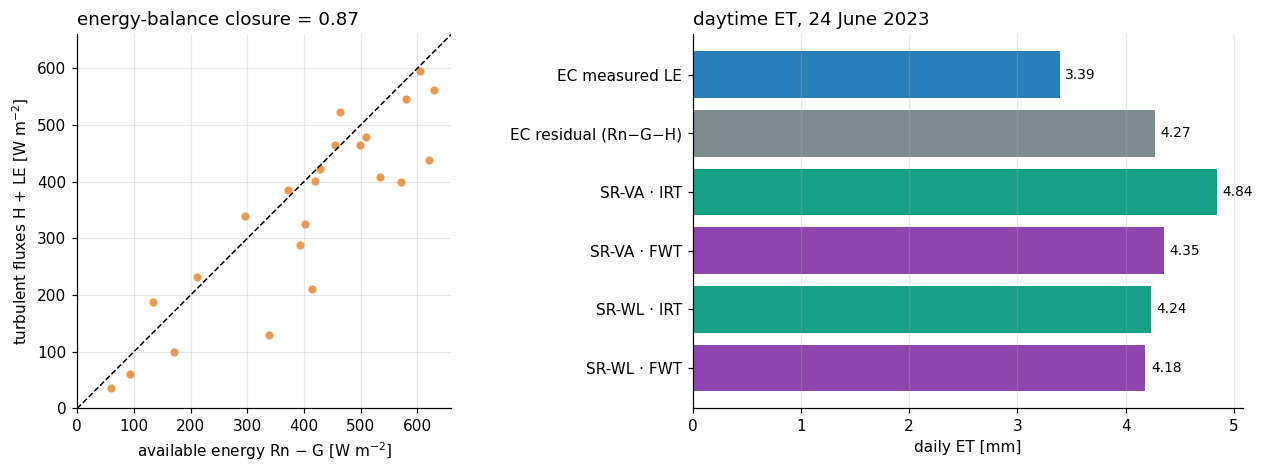

In [8]:
LAMBDA = 2.45e6
day = d[d.daytime].copy()

et = {}
for (meth, col), fit in fits.items():
    H_sr = sensible_heat(day[f"{meth}_{col}_F"].to_numpy(), fit.alpha, sign=+1.0)
    le = latent_heat_residual(day.NETRAD.to_numpy(), day.G.to_numpy(), H_sr)
    et[f"SR-{meth} · {col}"] = daily_et(le, block_s=BLOCK_S)

et["EC residual (Rn−G−H)"] = daily_et(
    latent_heat_residual(day.NETRAD.to_numpy(), day.G.to_numpy(), day.H.to_numpy()),
    block_s=BLOCK_S)
et["EC measured LE"] = daily_et(day.LE.to_numpy(), block_s=BLOCK_S)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.4))

avail = (day.NETRAD - day.G).to_numpy()
turb = (day.H + day.LE).to_numpy()
lim = [0, max(avail.max(), turb.max()) * 1.05]
axa.scatter(avail, turb, s=38, color="#e67e22", alpha=0.8, edgecolors="white")
axa.plot(lim, lim, "k--", lw=1)
sl = np.sum(avail * turb) / np.sum(avail ** 2)
axa.set(xlim=lim, ylim=lim, aspect="equal",
        xlabel="available energy Rn − G [W m$^{-2}$]",
        ylabel="turbulent fluxes H + LE [W m$^{-2}$]")
axa.set_title(f"energy-balance closure = {sl:.2f}", loc="left")

names = list(et)
axb.barh(names, [et[k] for k in names],
         color=["#8e44ad", "#16a085", "#8e44ad", "#16a085", "#7f8c8d", "#2980b9"])
axb.set_xlabel("daily ET [mm]")
axb.set_title("daytime ET, 24 June 2023", loc="left")
for i, k in enumerate(names):
    axb.text(et[k] + 0.05, i, f"{et[k]:.2f}", va="center", fontsize=9)
axb.grid(axis="y", alpha=0)
plt.tight_layout()

pd.Series(et).round(2).to_frame("ET [mm]")

The measured-LE bar sits below the residual bars because this tower, like most, does not
close its energy balance — the residual method assigns the missing energy to LE. That gap
is a property of the site, not of surface renewal, and it is why calibrating against a
closure-corrected H is preferable when one is available.

## Takeaways

1. **SR-WL on the fine wire is the clear winner here** (r = 0.97): a single multiplicative
   constant reproduces the tower's H across the day. SR-WL on the canopy skin is usable
   (r = 0.63) and SR-VA on the fine wire is intermediate (r = 0.78).
2. **SR-VA on the skin temperature fails on this day** (r ≈ 0). Its per-block Chen lag
   ranges from 15 s to over 300 s, and since the flux is A/tau, a noisy period scatters the
   estimate. Over a full record it recovers (the multi-year study behind this package gets
   r ≈ 0.6–0.85 for VA on surface temperature); one day of 23 blocks is not enough to
   average that noise out. Do not read a single day as a verdict on a method.
3. **The temperature-only flux direction did not work on the air channel here** — 0 %
   agreement with the tower, because the air ramps at this site are cold excursions from a
   canopy that sits 4 K below air temperature. Check the agreement rate before relying on
   the skewness sign, and prefer `sign_from_stability` when a sonic exists.
4. Compare `α·z`, not α, whenever the length-scale convention differs — only the product is
   identifiable from data.
5. One day demonstrates the method and is nowhere near enough to calibrate it: plan on
   10–21 days spread across conditions, not one continuous campaign.